<a href="https://colab.research.google.com/github/i1shhd/genai-bootcamp-lab1/blob/main/W2S2_Lab_HF_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Lab — pipeline() & a Prompt-Template Helper</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 2 · Session 2 — Building with Python & Hugging Face</div>
    </div>
    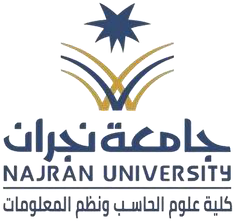
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENL track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: ≈ 45 minutes</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Run real NLP tasks with the Hugging Face <b><code>pipeline()</code></b> API.</li>
<li style="margin:5px 0;">Use <b>sentiment</b>, <b>zero-shot</b>, <b>summarization</b> and <b>NER</b> out of the box.</li>
<li style="margin:5px 0;">Try an <b>Arabic</b> example with a model that supports it.</li>
<li style="margin:5px 0;">Load <b>Qwen2.5-1.5B-Instruct</b> and build a reusable prompt-template helper.</li>
<li style="margin:5px 0;">Get reliable <b>structured JSON</b> back from the model.</li></ul></div>

## How to use this notebook

Run the cells **in order**, top to bottom (`Shift+Enter`). Read the short notes before each part — they connect the code back to today's slides. Every core model here is **open and ungated**: no Hugging Face token or login is required.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 First: turn on the free GPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click <b>Runtime → Change runtime type → T4 GPU → Save</b>. The pipelines run on CPU too, but the GPU makes the Qwen model in Part 5 much faster.</div></div>

### Setup
Colab already includes PyTorch. We just add the latest Transformers library.

In [1]:
# One-time setup (takes ~30-60 seconds)
!pip -q install -U "transformers>=4.44" accelerate
print("Setup complete — now run the cells below in order.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 29.6 MB/s eta 0:00:00
Setup complete — now run the cells below in order.


## Part 1 — Sentiment analysis with `pipeline()`

The `pipeline()` helper bundles three steps into one call: **tokenize → run the model → post-process**. Give it a task name and it downloads a sensible default model for you.

In [2]:
from transformers import pipeline

# Pin the model explicitly so everyone gets the same result.
sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
)
print(sentiment("I really love this bootcamp, the labs are excellent!"))
print(sentiment("The wifi kept dropping and it was frustrating."))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998800754547119}]
[{'label': 'NEGATIVE', 'score': 0.9991273283958435}]


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ What you get back</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">A list of dicts like <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">[{'label': 'POSITIVE', 'score': 0.999}]</code>. The <b>score</b> is the model's confidence (0-1) in that label.</div></div>

### Batching — pass a list, not a loop
Sending several texts at once lets the model process them together, which is much faster than a Python loop.

In [3]:
reviews = [
    "Best workshop I have attended this year.",
    "It was okay, nothing special.",
    "Terrible — I learned nothing useful.",
]
for review, result in zip(reviews, sentiment(reviews)):
    print(f"{result['label']:8s} ({result['score']:.2f})  <-  {review}")

POSITIVE (1.00)  <-  Best workshop I have attended this year.
NEGATIVE (0.98)  <-  It was okay, nothing special.
NEGATIVE (1.00)  <-  Terrible — I learned nothing useful.


## Part 2 — Zero-shot classification

What if your categories are not POSITIVE/NEGATIVE? **Zero-shot** classification lets you invent the labels at runtime — no training needed. The model scores how well the text fits each label you give it.

In [4]:
zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
)

text = "My order arrived broken and I want a refund immediately."
labels = ["billing", "technical support", "complaint", "praise"]

result = zero_shot(text, candidate_labels=labels)
for label, score in zip(result["labels"], result["scores"]):
    print(f"{label:18s} {score:.3f}")

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

complaint          0.914
billing            0.066
technical support  0.016
praise             0.005


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 When to use which classifier</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Use a <b>fine-tuned</b> classifier when your labels are fixed (like sentiment). Use <b>zero-shot</b> when the categories change or are custom to your app.</div></div>

## Part 3 — Summarization

A summarization pipeline shortens a long passage into a few sentences.

In [5]:
summarizer = pipeline(
    "text-generation",
    model="sshleifer/distilbart-cnn-12-6",
)

article = (
    "Hugging Face is a company and open-source community that builds tools for machine learning. "
    "Its Transformers library lets developers download and run thousands of pretrained models with "
    "only a few lines of Python. The Hub hosts millions of models, datasets and interactive demos "
    "called Spaces, making it a central place for the AI community to share work. Beginners can use "
    "the high-level pipeline API, while advanced users reach for the Auto classes for full control."
)
summary = summarizer(article, max_length=60, min_length=20, do_sample=False)
print(summary[0]["generated_text"])

config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'min_length', 'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Hugging Face is a company and open-source community that builds tools for machine learning. Its Transformers library lets developers download and run thousands of pretrained models with only a few lines of Python. The Hub hosts millions of models, datasets and interactive demos called Spaces, making it a central place for the AI community to share work. Beginners can use the high-level pipeline API, while advanced users reach for the Auto classes for full control.


## Part 4 — Named Entity Recognition (NER)

NER finds **people, places and organisations** in text. We group sub-word pieces back into whole words with `aggregation_strategy="simple"`.

In [6]:
ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",
)

text = "Najran University hosted a Generative AI bootcamp with NVIDIA in Saudi Arabia."
for ent in ner(text):
    print(f"{ent['entity_group']:6s} {ent['score']:.2f}  {ent['word']}")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

ORG    0.99  Najran University
MISC   0.97  Generative AI
ORG    0.99  N
ORG    0.75  ##VIDIA
LOC    1.00  Saudi Arabia


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Entity tags</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;"><code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">PER</code> = person, <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">LOC</code> = location, <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">ORG</code> = organisation, <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">MISC</code> = miscellaneous. The <b>score</b> is the model's confidence for each entity it found.</div></div>

### An Arabic example
`dslim/bert-base-NER` is English-only. For Arabic we pick a model whose card says it supports Arabic — here a multilingual NER model. (It downloads ~700 MB the first time.)

In [7]:
# Multilingual NER — the model card lists Arabic among supported languages.
ner_ar = pipeline(
    "ner",
    model="Davlan/bert-base-multilingual-cased-ner-hrl",
    aggregation_strategy="simple",
)

arabic = "زار محمد جامعة نجران في المملكة العربية السعودية."
for ent in ner_ar(arabic):
    print(f"{ent['entity_group']:6s} {ent['score']:.2f}  {ent['word']}")

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/709M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/264 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

PER    1.00  محمد
ORG    0.89  جامعة
ORG    0.87  نجران
LOC    1.00  المملكة العربية السعودية


<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENL</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">The <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">pipeline()</code> API and the standard NLP tasks (classification, summarization, NER, generation) sit in the <b>Software Development</b> domain — the second-largest on the exam. Know what each task returns and that you must match a model to a task <b>and</b> to the language.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Reuse the <b>zero-shot</b> pipeline to sort short messages into your own categories. Change the text and the labels, then run it.</div></div>

In [8]:
# Edit the text and the candidate labels, then run
my_text   = "I would love to have a dark mode option in the mobile application"
my_labels = ["bug report", "feature request", "question", "feedback"]

res = zero_shot(my_text, candidate_labels=my_labels)
print("Top label:", res["labels"][0], f"({res['scores'][0]:.2f})")

Top label: feature request (0.89)


## Part 5 — Build a prompt-template helper (Qwen2.5-1.5B-Instruct)

Pipelines are great for fixed tasks. For flexible work we use an **instruct** model and write our prompts in code. `Qwen2.5-1.5B-Instruct` is open, ungated and fits the free T4 GPU (~3 GB in fp16). It is also multilingual and strong at producing JSON.

In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"   # open & ungated
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,   # half precision fits the T4
    device_map="auto",           # use the GPU if one is available
)
print("Model loaded on:", next(model.parameters()).device)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded on: cuda:0


<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ If this is very slow</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">You are probably on CPU. Switch to a GPU runtime (see the setup box at the top) and re-run the cell.</div></div>

### A reusable chat helper
Instruct models expect a **chat template** (system / user roles). This helper wraps it so we can just pass a system instruction and a user message.

In [10]:
def chat(user_msg, system_msg="You are a helpful assistant.",
         max_new_tokens=256, **gen_kwargs):
    """Send a system+user message through the chat template and return the reply text."""
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user",   "content": user_msg},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)
    out = model.generate(
        input_ids=inputs['input_ids'],
        attention_mask=inputs['attention_mask'],
        max_new_tokens=max_new_tokens,
        do_sample=False,                       # deterministic by default 0
        pad_token_id=tokenizer.eos_token_id, **gen_kwargs,
    )
    return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print(chat("In one sentence, what is the Hugging Face Hub?"))

The Hugging Face Hub is a platform for sharing and using pre-trained models in natural language processing tasks.


### A prompt template that asks for structured JSON
Now the reusable part: a Python function that builds a **prompt template** describing the exact fields we want, plus a small helper that safely parses the JSON the model returns.

In [11]:
import json, re

def build_extraction_prompt(text, fields):
    """Return a prompt asking the model to extract `fields` from `text` as JSON."""
    field_list = ", ".join(fields)
    return (
        f"Extract the following fields from the text: {field_list}.\n"
        f"Return ONLY a valid JSON object with exactly these keys: {field_list}.\n"
        f"If a field is missing, use null.\n\n"
        f"Text:\n\"\"\"{text}\"\"\""
    )

def extract_json(raw):
    """Pull the first {...} block out of the model output and parse it."""
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        return {"_error": "no JSON found", "_raw": raw}
    try:
        return json.loads(match.group(0))
    except json.JSONDecodeError:
        return {"_error": "invalid JSON", "_raw": raw}

In [12]:
SYSTEM = "You are a precise information-extraction assistant. You only output valid JSON."

review = ("My name is Sara Ali. I bought the Pro headphones for 350 SAR in Riyadh "
          "and the sound quality is amazing, but the battery life is disappointing.")

prompt = build_extraction_prompt(
    review,
    fields=["customer_name", "product", "price", "city", "sentiment"],
)
raw = chat(prompt, system_msg=SYSTEM, max_new_tokens=200)
data = extract_json(raw)

print("Parsed object:", data)
print("\nProduct field:", data.get("product"))

Parsed object: {'customer_name': 'Sara Ali', 'product': 'Pro headphones', 'price': 350, 'city': 'Riyadh', 'sentiment': 'positive'}

Product field: Pro headphones


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Why this works reliably</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">We (1) <b>ask explicitly</b> for JSON and name the keys, (2) generate with <b>do_sample=False</b> so the format is stable, and (3) <b>parse defensively</b> by extracting the <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">{...}</code> block. This is the structured-output pattern from the slides.</div></div>

### The helper is multilingual — try Arabic
Because Qwen2.5 supports Arabic, the same helper works on Arabic text with no changes.

In [13]:
arabic_review = "اسمي خالد من جدة، اشتريت ساعة ذكية بسعر 600 ريال والجودة ممتازة لكن البطارية ضعيفة."

prompt_ar = build_extraction_prompt(
    arabic_review,
    fields=["customer_name", "product", "price", "city", "sentiment"],
)
data_ar = extract_json(chat(prompt_ar, system_msg=SYSTEM, max_new_tokens=200))
print(data_ar)

{'customer_name': 'خالد', 'product': 'ساعة ذكية', 'price': '600 ريال', 'city': 'جدة', 'sentiment': 'متفائل'}


<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Reuse <code>build_extraction_prompt</code> for a <b>new schema</b>. Change the text and the list of fields (for example extract a job posting's title, company, location and skills).</div></div>

In [14]:
# Edit the text and the fields, then run
my_text = ("We are hiring a Data Scientist at Vision AI Solutions in Riyadh. "
    "Required skills: Python, TensorFlow, SQL, and Machine Learning.")
my_fields = ["job_title", "company", "location", "skills"]

result = extract_json(chat(build_extraction_prompt(my_text, my_fields),
                           system_msg=SYSTEM, max_new_tokens=200))
print(result)

{'job_title': 'Data Scientist', 'company': 'Vision AI Solutions', 'location': 'Riyadh', 'skills': ['Python', 'TensorFlow', 'SQL', 'Machine Learning']}


## Part 6 — (Optional) Compare with a hosted API

Want to see how a small local model compares with a frontier-scale hosted one? Google AI Studio has a **free tier**. This part is entirely optional and safe to skip.

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Optional — needs a free key</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">1) Get a free key at <b>aistudio.google.com/apikey</b>.  2) In Colab click the 🔑 (left sidebar) and add a secret named <b>GOOGLE_API_KEY</b>.  Then run the cell. Skip this if you prefer to stay fully offline.</div></div>

In [15]:
# OPTIONAL — safe to skip
!pip -q install -U google-genai
from google import genai
from google.colab import userdata

client = genai.Client(api_key=userdata.get("GOOGLE_API_KEY"))
resp = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=build_extraction_prompt(review,
        fields=["customer_name", "product", "price", "city", "sentiment"]),
)
print(resp.text)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 984.2/984.2 kB 39.0 MB/s eta 0:00:00
```json
{
  "customer_name": "Sara Ali",
  "product": "Pro headphones",
  "price": "350 SAR",
  "city": "Riyadh",
  "sentiment": "mixed"
}
```


<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;"><b><code>pipeline(task, model=...)</code></b> runs a model in two lines: tokenize → model → post-process.</li>
<li style="margin:5px 0;">Core NLP tasks: <b>sentiment</b>, <b>zero-shot</b>, <b>summarization</b>, <b>ner</b>, <b>text-generation</b>.</li>
<li style="margin:5px 0;">Match a model to the <b>task and the language</b> — and prefer <b>ungated</b> models (no token).</li>
<li style="margin:5px 0;">Instruct models need a <b>chat template</b>; wrap prompts in reusable <b>Python functions</b>.</li>
<li style="margin:5px 0;">For structured output: ask for <b>JSON</b>, use <b>do_sample=False</b>, and <b>parse defensively</b>.</li>
<li style="margin:5px 0;"><b>Batch</b> a list of inputs and load the model <b>once</b> for speed.</li></ul></div>

---
### Save your work
Commit this notebook to your **`genai-bootcamp-lab1`** GitHub repo from the Week-1 setup lab (`File → Save a copy in GitHub`). Next session: embeddings, semantic search and RAG — where you'll reuse this prompt-template helper.